# Assignment: Encoder, Decoder & Parameters in Large Language Models (LLM)



**Instructions:** Answer all questions. Do not use AI-generated answers. Write clean, well-commented code where required.

## Question 1

Explain the difference between Encoder-only and Decoder-only architectures with a real-world example not discussed in class.

**Answer:** Encoder-only models read the whole sentence at once, both before and after a word, so they build a strong understanding of context. They're not really made for generating new text, but they're great at tasks like classification or understanding meaning and relationships between words. BERT is a good example of this type.

Decoder-only models work differently. They read text only from left to right and predict the next word based on what came before it. That's basically their whole job, guessing the next word one at a time, which makes them really good at generating text. GPT is a classic example of this.

**Real world example :**
Think about Grammarly compared to Gmail's Smart Compose feature.
Grammarly needs to look at your entire sentence, including words before and after, to check grammar and tone properly. That's similar to how an encoder-only model works since it needs full context to judge something correctly.

Gmail Smart Compose is different. It only looks at what you've typed so far and tries to guess what you'll type next. It doesn't know the rest of the sentence because it hasn't been written yet. This is exactly how a decoder-only model behaves.
So basically, encoder-only models are good at understanding text, and decoder-only models are good at generating text.

## Question 2

Why is bidirectional context useful for text understanding? Give two NLP tasks where it is beneficial.

**Answer:** Bidirectional context means the model looks at words coming before and after a given word, not just one side. This gives it the full picture of a sentence, so it understands the actual meaning instead of guessing from half the information.
Example:

* I will meet you at the bank.

* She left her book near the bank of the river.

Just seeing the word "bank" alone doesn't tell you much. But once you read the rest of the sentence on both sides, it becomes clear whether it means a financial bank or a riverbank.
Two NLP tasks where this helps:

1. Sentiment Analysis: Sometimes a sentence starts one way and flips later. Example: "The service was slow, but honestly the food made up for it." If a model only reads left to right, it might tag this as negative early on. Reading both sides helps it realize the overall sentiment is actually positive.

2. Named Entity Recognition (NER): Words can have different meanings depending on what surrounds them. Example: "Delhi recorded record rainfall this week." Here "Delhi" is clearly a location because of the words around it, and bidirectional context helps the model tag it correctly instead of confusing it with anything else.

## Question 3

Why can't a Decoder see future tokens during training? Explain with an example.

**Answer:** Because a decoder predicts the next word using only the words before it, this is called autoregressive generation. It uses masked self-attention to block future words during training. If it could see future tokens, it would just copy the answer instead of learning to predict it, and that's called data leakage.

Example:
Sentence: "I love playing cricket."

To predict "love," it can only see "I"

To predict "playing," it can only see "I love"

To predict "cricket," it can only see "I love playing"

If it could already see the whole sentence while predicting "playing," it would just copy the word instead of actually learning anything. That's why decoders are kept blind to future tokens.

## Question 4

Compare BERT and GPT in terms of architecture, training objective, input visibility, and applications.

**Answer:** BERT is encoder-only, it reads the full sentence at once. GPT is decoder-only, it generates text one word at a time, left to right.

Training objective:

BERT is trained using masked language modeling, meaning it hides some random words in a sentence and tries to guess them using context from both sides. GPT is trained to predict the next word in a sequence, using only the words that came before it.

Input visibility:

BERT can see the whole sentence at once, both left and right context. GPT can only see past words, it has no access to future words since it's generating them step by step.

Applications:

BERT is mostly used for understanding tasks like sentiment analysis, question answering, and named entity recognition. GPT is mostly used for generation tasks like writing text, chatbots, summarization, and completing sentences.

Example to make it simple: BERT is like a student solving a fill in the blanks question using the full paragraph. GPT is like a student writing an essay one word at a time without knowing what comes next.

## Question 5

Draw the workflow of Encoder and Decoder using Mermaid or ASCII art.

**Answer:**

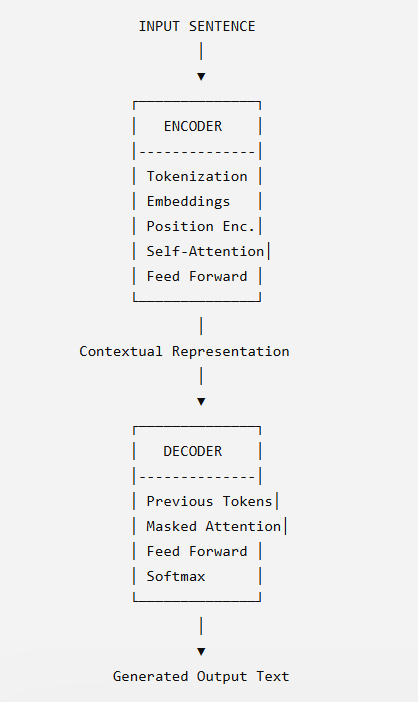

## Question 6

Predict which model (BERT or GPT) is better for: Sentiment Analysis, Chatbot, Text Summarization, Masked Word Prediction, Code Generation. Justify.

**Answer:**

Sentiment Analysis → BERT
Since sentiment analysis needs the model to understand the full sentence and its context from both sides, BERT works better here. It can look at words before and after to correctly judge whether something is positive or negative, especially in tricky sentences like "not bad" or "not good."

Chatbot → GPT
Chatbots need to generate replies word by word based on the conversation so far. That's exactly what GPT is built for, predicting the next word using only past context. BERT can't do this well since it's not designed to generate new text.

Text Summarization → GPT
Summarization involves generating new sentences that capture the meaning of a longer text. Since this needs actual text generation, GPT is more suitable. GPT style models can read the input and generate a shorter version word by word.

Masked Word Prediction → BERT
This one is literally what BERT is trained on. It hides random words in a sentence and tries to predict them using context from both sides, so BERT is naturally the better fit here.

Code Generation → GPT
Code generation means writing code line by line based on what came before, similar to writing normal text. GPT works well here since it generates output sequentially, predicting the next token (word or code snippet) based on everything written before it.

## Question 7

What is Masked Self-Attention? Explain why it prevents cheating.

**Answer:**

Masked self attention, also called causal self attention, is where each word can only attend to itself and the words before it. It's not allowed to look at future words since they're hidden, or masked, from it.

Why it prevents cheating:

During training, the whole sentence is fed in together for speed. But without the mask, each word could just look at the answer it's supposed to predict, making training pointless. And that's not how real generation works anyway, since at the time of actually generating text, future words don't even exist yet.

Example:
Sentence: "I love playing cricket."

While predicting "playing," the model can only see "I love." It's not allowed to see "playing" or "cricket" yet. This forces it to actually learn from context instead of memorizing the sentence.

## Question 8

Differentiate Parameters, Weights, and Biases with examples.

**Answer:**

Parameters is the overall term for everything a model learns, it includes both weights and biases together.

Weights decide how much importance is given to an input, they control the strength of connection between neurons.

Biases are extra values added to shift the output, they give the model more flexibility instead of forcing it through zero.

Example:

y = wx + b

Here w is weight, b is bias, and both together are called parameters. If x = 2, w = 3, b = 1, then y = 7.

## Question 9

If a model has 15 billion parameters stored in FP16, estimate the memory required.

**Answer:**

FP16 means each parameter takes up 2 bytes of memory.

So memory = 15 billion × 2 bytes = 30 billion bytes = around 30 GB

That's just for storing the model weights, actual usage during training or inference can be higher because of extra stuff like gradients, optimizer states, and activations.

## Question 10

Estimate memory for a 70B parameter model in FP32.

**Answer:**

Estimate: Memory for 70B parameters in FP32
FP32 means each parameter takes up 4 bytes of memory.

So memory = 70 billion × 4 bytes = 280 billion bytes = around 280 GB

That's a lot more than FP16 since FP32 uses double the bytes per parameter. This is also why most large models prefer FP16 or even lower precision, it saves a huge amount of memory while still keeping decent accuracy.

## Question 11

Write Python code using transformers pipeline to perform a fill-mask task.

**Answer:**

In [1]:
!pip install transformers

In [3]:
from transformers import pipeline

unmasker = pipeline('fill-mask', model='bert-base-uncased')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [9]:
result = unmasker("The capital of India is [MASK].")

for r in result:
    print(r['sequence'], "-> score:", round(r['score'], 4))

the capital of india is mumbai. -> score: 0.1768
the capital of india is delhi. -> score: 0.1531
the capital of india is pune. -> score: 0.1392
the capital of india is hyderabad. -> score: 0.065
the capital of india is bangalore. -> score: 0.0643


## Question 12

Write Python code using GPT-2 to generate text from a prompt.

**Answer:**

In [12]:
from transformers import pipeline

generator = pipeline('text-generation', model='gpt2')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [13]:
prompt = "Artificial Intelligence is going to"
result = generator(prompt, max_length=50, num_return_sequences=1)
print(result[0]['generated_text'])

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Artificial Intelligence is going to make the world a better place.

An American company called AI-Ready, which uses AI capabilities to build artificial intelligence to solve complex problems, has announced that it will produce 3D printed humanoid robots for the US Army.

That means that by 2020, the Pentagon's goal is to create at least 3D printed humanoid robots capable of moving around, eating and running.

The company plans to manufacture humanoid robots for the US Army, the Pentagon and other military departments.

The machines would be made out of artificial intelligence software, which can be programmed to make specific tasks, such as taking out trash cans.

"We're looking at things like driving machines or doing things like doing things like that, but we could also be making robots that are intelligent machines and will perform tasks very similar to humans," said David Kessel, chief executive officer of AI-Ready.

"We will see machines that work in a way they are not programmed 

## Question 14

Research Question: Compare Encoder-only, Decoder-only and Encoder-Decoder architectures in a table.

**Answer:**

**Research Question: Comparing Encoder-only, Decoder-only, and Encoder-Decoder architectures**

| Feature | Encoder-only (BERT) | Decoder-only (GPT) | Encoder-Decoder (T5, BART) |
|---|---|---|---|
| Context visibility | Sees both left and right words | Sees only past words | Encoder sees full input, decoder sees only past output |
| Training objective | Masked language modeling | Next word prediction | Sequence to sequence (input to output mapping) |
| Main strength | Understanding text | Generating text | Both understanding and generating |
| Attention type | Full self attention | Masked (causal) self attention | Full attention in encoder, masked attention in decoder |
| Best for | Classification, NER, sentiment analysis | Chatbots, text generation, code generation | Translation, summarization, question answering |
| Example models | BERT, RoBERTa | GPT, GPT2, GPT3 | T5, BART, original Transformer |


## Question 15

Debug: Find and fix five possible issues in the provided BERT/GPT implementation (internet, package, model name, memory, token).

**Answer:**

1. No Internet Connection
Issue: The model cannot be downloaded from the Hugging Face Hub if there is no internet connection.
Fix: Connect to the internet during the first run or download the model beforehand and load it from a local directory.

2. Required Packages Not Installed
Issue: You may get an error such as ModuleNotFoundError: No module named 'transformers'.
Fix: Install the required libraries using:

3. Incorrect Model Name
Issue: Using an invalid model name (e.g., bert-base instead of bert-base-uncased) results in an error.
Fix: Use the correct pretrained model names such as:
BERT: bert-base-uncased
GPT-2: gpt2

4. Memory (RAM/GPU) Issue
Issue: Large models may cause an Out of Memory (OOM) error.
Fix: Use smaller models like distilbert-base-uncased or distilgpt2, reduce the batch size, or use a GPU with more memory.

5. Incorrect Token
Issue: Using the wrong special token for the selected model.
Fix:
For BERT, use [MASK].
For RoBERTa, use <mask>.
For GPT, do not use a mask token because GPT generates text from a prompt.

## Question 17

Interview Q1: Why do larger parameter counts not always produce better performance?

**Answer:**

Performance doesn't just depend on how many parameters a model has, it also depends on the quality of data, how well the model is trained, and the architecture used.

Reasons:

* Overfitting: A large model can end up memorizing the training data instead of actually learning patterns, which hurts its performance on new, unseen data.

* Poor data quality: If the data used for training isn't good or is too limited, having more parameters doesn't help much, the model just doesn't have enough useful information to learn from.

* Cost goes up: Bigger models need way more GPUs, memory, and time to train, which isn't always practical or worth it.

* Diminishing returns: After a certain size, adding more parameters barely improves results, but the cost keeps increasing a lot.

* Slower to use: Bigger models take longer to generate outputs, which can be a problem for anything that needs quick, real-time responses.

## Question 18

Interview Q2: What happens if model weights are randomly initialized and never trained?

**Answer:**

If the weights stay random and are never trained, the model basically stays useless. It has no idea what patterns exist in the data, so its outputs would just be random guesses with no real meaning.

For example, if you gave an untrained model a sentence and asked it to predict the next word, it would just spit out random words since the weights were never adjusted to actually learn relationships between words.

Training is what changes these random weights step by step using backpropagation, so the model slowly learns to make better predictions instead of random ones. Without that process, no matter how many parameters the model has, it won't perform any better than random chance.

## Question 20

Mini Project: Build a notebook demonstrating BERT fill-mask and GPT text generation, compare outputs, limitations, runtime, and conclusions.

**Answer:**

In [14]:
!pip install transformers

from transformers import pipeline
import time

BERT fill-mask task

In [15]:
unmasker = pipeline('fill-mask', model='bert-base-uncased')

start = time.time()
bert_result = unmasker("Artificial Intelligence is going to [MASK] the world.")
bert_time = time.time() - start

for r in bert_result:
    print(r['sequence'], "-> score:", round(r['score'], 4))

print("BERT runtime:", round(bert_time, 3), "seconds")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


artificial intelligence is going to change the world. -> score: 0.5863
artificial intelligence is going to rule the world. -> score: 0.0839
artificial intelligence is going to dominate the world. -> score: 0.069
artificial intelligence is going to destroy the world. -> score: 0.047
artificial intelligence is going to control the world. -> score: 0.0304
BERT runtime: 0.177 seconds


In [16]:
generator = pipeline('text-generation', model='gpt2')

start = time.time()
gpt_result = generator("Artificial Intelligence is going to", max_length=30, num_return_sequences=1)
gpt_time = time.time() - start

print(gpt_result[0]['generated_text'])
print("GPT2 runtime:", round(gpt_time, 3), "seconds")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Artificial Intelligence is going to be a big part of how we're going to move towards this. There will be no more artificial intelligence, which means we're going to be able to generate more and more ideas for our products.

It's going to be really cool to have a solution for everything your customers want. The next step is going to be to create a market in which you can actually generate the most value for them. And I think that's going to be a very exciting thing.

Now, it's important to note that this isn't a new idea. We've been talking about this for a while, and it's sort of a natural extension of what's been done with machine learning.

When we say AI, I have to be very careful not to overstate how good our AI technology is.

It's always been something that we've had to make sure that every piece of it is good — in terms of the whole ecosystem.

We are using machine learning and artificial intelligence to make our data more easily and quickly accessible to people.

The next step 

Limitations:

BERT can only fill in one masked word at a time and doesn't generate longer text on its own, it's not built for that. It also needs the exact [MASK] token to work properly.

GPT2 sometimes generates text that sounds fine grammatically but doesn't always make complete sense or stay on topic, especially with longer outputs. It also runs slower since it generates one token at a time instead of doing it all at once like BERT.